# Week 4, Day 4

## Model Tuning, Regularization & Reproducible Pipelines

This notebook continues directly from Week 4 Day 3. Day 3 ended with two candidate
models carried forward on cross validated F1: **Hist Gradient Boosting** (CV F1 = 0.7084)
as the top performer and **Logistic Regression** (CV F1 = 0.6752) as the interpretable
runner up, both using the 20 column engineered feature set (5 raw numeric, 7 raw
categorical, 8 engineered). Random Forest was dropped after Day 3 since it was both the
weakest performer and the slowest to train, so it is not carried into today's search.

Today's goal is to turn those two candidates into tuned, calibrated, reproducible
pipelines, diagnose their bias/variance behaviour, pick a deployment threshold against
the F1 business metric established on Day 1, and produce one saved artifact plus a short
tuning report.

Because Day 3's fitted pipeline objects were not persisted to disk, the first few cells
below rebuild the exact same data splits and feature engineering pipeline from Day 3
(same `RANDOM_STATE`, same bin edges, same column lists) so this notebook can be run
standalone and still land on identical splits. This was verified against Day 3's printed
shapes and class balances before writing anything else in this notebook.

## Recap: rebuilding the Day 3 state

Everything below this point through the "Day 3 recap ends" marker is not new work,
it is a faithful reproduction of Day 1 to Day 3 so that `train_df`, `dev_df`, `test_df`,
and the engineered feature pipeline are available in this session. If you are running
this notebook directly after Day 3 in the same kernel, you can skip straight to Task 1
and reuse your existing objects instead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings

import sklearn
import scipy
import joblib

RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)

print("Library versions used in this notebook:")
print(f"  numpy       : {np.__version__}")
print(f"  pandas      : {pd.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")
print(f"  scipy       : {scipy.__version__}")
print(f"  joblib      : {joblib.__version__}")

Library versions used in this notebook:
  numpy       : 2.5.1
  pandas      : 3.0.3
  scikit-learn: 1.9.0
  scipy       : 1.18.0
  joblib      : 1.5.3


In [2]:
# Same load + split logic as Day 1 / Day 3, unchanged
column_names = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
df = pd.read_csv(url, header=None, names=column_names, na_values="?", skipinitialspace=True)

df["income"] = df["income"].str.strip().str.rstrip(".")
df["target"] = (df["income"] == ">50K").astype(int)

from sklearn.model_selection import train_test_split

train_dev_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df["target"], random_state=RANDOM_STATE
)
train_df, dev_df = train_test_split(
    train_dev_df, test_size=0.125, stratify=train_dev_df["target"], random_state=RANDOM_STATE
)

print(f"Train: {len(train_df)}  Dev: {len(dev_df)}  Test: {len(test_df)}")
print(f"Positive share  train/dev/test: "
      f"{train_df['target'].mean():.4f} / {dev_df['target'].mean():.4f} / {test_df['target'].mean():.4f}")

Train: 34188  Dev: 4885  Test: 9769
Positive share  train/dev/test: 0.2393 / 0.2393 / 0.2393


In [3]:
# Same feature engineering as Day 3, unchanged. Fixed bin edges, no leakage:
# every rule reads only columns already present on that same row.
numeric_cols = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_features = ["workclass", "marital-status", "occupation", "relationship",
                         "race", "sex", "native-country"]
feature_cols = numeric_cols + categorical_features

AGE_BINS = [0, 25, 35, 45, 55, 65, 100]
AGE_LABELS = ["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]
HOURS_BINS = [0, 20, 35, 40, 50, 100]
HOURS_LABELS = ["part_time_le20", "reduced_21_35", "standard_36_40", "over_41_50", "heavy_50plus"]

def engineer_features(frame):
    out = frame.copy()
    out["age_bucket"] = pd.cut(out["age"], bins=AGE_BINS, labels=AGE_LABELS, right=True)
    out["hours_bucket"] = pd.cut(out["hours-per-week"], bins=HOURS_BINS, labels=HOURS_LABELS, right=True)
    out["has_capital_gain"] = (out["capital-gain"] > 0).astype(int)
    out["has_capital_loss"] = (out["capital-loss"] > 0).astype(int)
    out["higher_education"] = (out["education-num"] >= 13).astype(int)
    out["log_capital_gain"] = np.log1p(out["capital-gain"])
    out["edu_hours_interaction"] = out["education-num"] * out["hours-per-week"]
    out["net_capital"] = out["capital-gain"] - out["capital-loss"]
    return out

engineered_numeric_cols = numeric_cols + ["log_capital_gain", "edu_hours_interaction", "net_capital"]
engineered_binary_cols = ["has_capital_gain", "has_capital_loss", "higher_education"]
engineered_categorical_cols = categorical_features + ["age_bucket", "hours_bucket"]

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer

numeric_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
binary_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])
categorical_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor_fe = ColumnTransformer([
    ("num", numeric_pipeline_fe, engineered_numeric_cols),
    ("bin", binary_pipeline_fe, engineered_binary_cols),
    ("cat", categorical_pipeline_fe, engineered_categorical_cols),
])
feature_engineer = FunctionTransformer(engineer_features, validate=False)

X_train, y_train = train_df[feature_cols], train_df["target"]
X_dev, y_dev = dev_df[feature_cols], dev_df["target"]
X_test, y_test = test_df[feature_cols], test_df["target"]

# Sanity check against Day 3's confirmed output shape (34188, 104)
_check = Pipeline([("fe", feature_engineer), ("prep", preprocessor_fe)]).fit_transform(X_train, y_train)
print("Transformed train shape:", _check.shape)
assert _check.shape == (34188, 104), "Split or feature engineering has drifted from Day 3"
del _check
print("Day 3 recap ends. Shapes match, safe to proceed.")

Transformed train shape: (34188, 104)
Day 3 recap ends. Shapes match, safe to proceed.


## Task 1: Build Fully Reproducible Pipelines

**Decision: one `Pipeline` per candidate model, all sharing the same
`feature_engineering -> preprocessing -> classifier` structure used in Day 3.**
Keeping the structure identical across candidates is what made Day 3's cross validated
comparison fair, and it is what lets `RandomizedSearchCV` in Task 2 tune only the
final estimator's hyperparameters without touching how features are built.

**Decision: `RANDOM_STATE = 42` is passed to every stochastic step.** That means the
train/dev/test split, `StratifiedKFold`, `LogisticRegression`, `RandomForestClassifier`
(if revisited), `HistGradientBoostingClassifier`, `RandomizedSearchCV`, and
`CalibratedClassifierCV` all receive the same seed. This is what makes "re run this
notebook top to bottom" produce the same numbers twice, the single most important
property for a tuning report anyone else needs to trust.

**Decision: only Logistic Regression and Hist Gradient Boosting are carried into
tuning.** Random Forest was both the weakest of the three models on Day 3's 5 fold CV
(F1 = 0.6654) and the slowest to fit (12.1s vs 3.2s and 4.8s), so tuning it further is
unlikely to change today's recommendation and would roughly double the search budget
for the two searches below. This choice is revisited only if both tuned models
underperform Day 3's baseline, which would suggest the model family itself, not the
hyperparameters, is the bottleneck.

The cell below is a short, runnable README documenting exactly how to reproduce every
result in this notebook.

In [ ]:
README = """
HOW TO REPRODUCE THIS NOTEBOOK
================================
1. Environment: see the printed library versions in the first code cell above.
   This notebook was built against scikit-learn >= 1.6 (uses sklearn.frozen.FrozenEstimator
   for calibration, which replaced the deprecated CalibratedClassifierCV(cv="prefit")).

2. Data: pulled fresh from
   https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv
   No local caching, so results depend on that file staying unchanged upstream.

3. Splits: 70 / 10 / 20 train / dev / test, stratified on target, RANDOM_STATE = 42.
   Test set (test_df) is touched exactly once, in Task 5. Everything else (search,
   learning curves, calibration, threshold tuning) uses only train_df and dev_df.

4. Run order: top to bottom. Task 2 search cells are the slowest part
   (RandomizedSearchCV with n_jobs=-1); everything after Task 2 assumes
   logreg_search and hgb_search (or their .best_estimator_ / best_params_) already
   exist in memory.

5. Outputs: the final artifact is saved to models/day4_final_pipeline.joblib in Task 5,
   together with the exact threshold and preprocessing needed to reuse it for inference.
"""
print(README)

**Decision: keep `Pipeline` (not `imblearn.Pipeline`).** No resampling (SMOTE,
undersampling) is being introduced today, the class imbalance (23.9 percent positive)
is being handled the way Day 1 to Day 3 already handled it, through the F1 metric and,
later today, through threshold selection rather than by rebalancing the training
distribution. If a resampling step were added later, this pipeline would need to switch
to `imblearn.pipeline.Pipeline` so that resampling only happens on the training fold
inside cross validation.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

logreg_pipe = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", preprocessor_fe),
    ("clf", LogisticRegression(solver="liblinear", max_iter=2000, random_state=RANDOM_STATE)),
])

hgb_pipe = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", preprocessor_fe),
    ("clf", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
])

print(logreg_pipe)
print()
print(hgb_pipe)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function engineer_features at 0x000001D215C9A8D0>)),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'log_capital_gain',...
                                                   'higher_education']),
   

## Task 2: Hyperparameter Search (Randomized)

**Decision: `RandomizedSearchCV` over `GridSearchCV`, `n_iter = 30` per model.**
With 2 hyperparameters for Logistic Regression and 4 for Hist Gradient Boosting, a
grid search over sensible ranges quickly reaches hundreds of combinations. Randomized
search with a fixed budget covers the same space more efficiently and is the standard
recommendation when tuning 2 or more continuous hyperparameters. `n_iter = 30` is on
the lower end of the 50 to 100 suggested range, this is a deliberate choice to keep
the search runnable in a normal notebook session; if compute time is not a constraint,
raise `n_iter` to 50 or higher for a more exhaustive search, the code does not change.

**Decision: same `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` object
used in Day 3's cross validated comparison.** Reusing it means the folds inside this
search are the same folds Day 3's baseline numbers were computed on, so "CV F1 went
from 0.7084 to X" is a fair before/after comparison, not an artifact of a different
fold assignment.

**Decision: `scoring="f1"`**, matching the primary metric fixed since Day 1.

**Decision on Logistic Regression's parameter grid:** `penalty` in `["l1", "l2"]`
and `C` drawn from a log uniform distribution between 0.001 and 100. `C` is searched
on a log scale because it is a multiplicative regularization strength, equal spacing
on a linear scale would oversample large C values and undersample the small, strongly
regularized end. `solver="liblinear"` is used instead of Day 2 and Day 3's `lbfgs`
because `lbfgs` only supports the L2 penalty; `liblinear` supports both L1 and L2 and
remains fast at this dataset size (about 34k rows, 104 columns after preprocessing).

**Decision on Hist Gradient Boosting's parameter grid:** `learning_rate`,
`max_iter` (this estimator's equivalent of `n_estimators`), `max_depth`, and
`l2_regularization`, as specified in the task brief. Ranges below are centered on
scikit-learn's defaults (`learning_rate=0.1`, `max_iter=100`, `max_depth=None`,
`l2_regularization=0`) and widen out from there, since Day 3 already showed the
untuned defaults were strong, the best CV F1 of the three Day 3 models, so this search
is refining around a good starting point rather than exploring blindly.

In [7]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from scipy.stats import loguniform, randint

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

logreg_param_dist = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": loguniform(1e-3, 1e2),
}

logreg_search = RandomizedSearchCV(
    logreg_pipe,
    param_distributions=logreg_param_dist,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

start = time.time()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    logreg_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Logistic Regression search time: {elapsed:.1f}s")
print("Best params:", logreg_search.best_params_)
print("Best CV F1  :", round(logreg_search.best_score_, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Logistic Regression search time: 91.9s
Best params: {'clf__C': np.float64(3.4702669886504163), 'clf__penalty': 'l2'}
Best CV F1  : 0.6756


In [8]:
hgb_param_dist = {
    "clf__learning_rate": loguniform(0.01, 0.3),
    "clf__max_iter": randint(100, 500),
    "clf__max_depth": randint(3, 12),
    "clf__l2_regularization": loguniform(1e-4, 10),
}

hgb_search = RandomizedSearchCV(
    hgb_pipe,
    param_distributions=hgb_param_dist,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

start = time.time()
hgb_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Hist Gradient Boosting search time: {elapsed:.1f}s")
print("Best params:", hgb_search.best_params_)
print("Best CV F1  :", round(hgb_search.best_score_, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Hist Gradient Boosting search time: 154.4s
Best params: {'clf__l2_regularization': np.float64(5.140540420871591), 'clf__learning_rate': np.float64(0.06792740114629246), 'clf__max_depth': 11, 'clf__max_iter': 445}
Best CV F1  : 0.7095


In [9]:
# Side by side comparison against Day 3's untuned baseline numbers
search_summary = pd.DataFrame([
    {"model": "Logistic Regression (Day 3 default)", "cv_f1": 0.6752, "tuned": False},
    {"model": "Logistic Regression (tuned)", "cv_f1": logreg_search.best_score_, "tuned": True},
    {"model": "Hist Gradient Boosting (Day 3 default)", "cv_f1": 0.7084, "tuned": False},
    {"model": "Hist Gradient Boosting (tuned)", "cv_f1": hgb_search.best_score_, "tuned": True},
]).round(4)
search_summary

,model,cv_f1,tuned
0,Logistic Regression (Day 3 default),0.6752,False
1,Logistic Regression (tuned),0.6756,True
2,Hist Gradient Boosting (Day 3 default),0.7084,False
3,Hist Gradient Boosting (tuned),0.7095,True


Tuning moved CV F1 by +0.0004 for Logistic Regression and +0.0011 for Hist Gradient Boosting, both well within Day 3's measured fold-to-fold noise (std 0.006 to 0.007), so this counts as no material improvement over the untuned defaults for either model. Hist Gradient Boosting remains the stronger model on both the default and tuned comparison (0.7095 vs 0.6756), so it is carried into Task 3 and Task 4. The search settled on C=3.47 with L2 penalty for Logistic Regression (weak regularization, all features kept rather than zeroed out by L1), and for Hist Gradient Boosting: max_depth=11, learning_rate=0.068, max_iter=445, l2_regularization=5.14, a deeper, slower-learning, more heavily regularized ensemble than the defaults. The depth of 11 is deeper than Day 2's plain Decision Tree needed (capped at 8), this will be checked against Task 3's max_depth validation curve to confirm it reflects genuine signal rather than the search landing on an overfit configuration by chance.

## Task 3: Diagnose Overfitting / Underfitting

**Decision: pick the model with the higher tuned CV F1 from Task 2 as `best_search`
for the learning curve, but run validation curves for both model families as the
brief asks.** A learning curve (score vs training set size) diagnoses whether more
data would help; a validation curve (score vs one hyperparameter) diagnoses whether
regularization strength or tree depth is the lever to pull. These answer different
questions, so both are produced.

**Decision: `scoring="f1"` everywhere, `cv=cv`** (the same 5 fold `StratifiedKFold`
used throughout today) so these curves are directly comparable to the Task 2 numbers.

**Decision: Logistic Regression's validation curve sweeps `C`** on a log scale,
matching how it was searched in Task 2, this directly shows whether the tuned `C`
sits in a stable region or right at the edge of overfitting or underfitting.

**Decision: Hist Gradient Boosting's validation curve sweeps `max_depth`.**
`max_depth` was chosen over `min_samples_leaf` because Day 2's plain Decision Tree
showed depth was already the effective lever for controlling its train/test gap
(depth capped at 8 gave a gap of only 0.0025), so depth is the more informative axis
to check first for the boosted version too.

Learning curve computed for: Hist Gradient Boosting


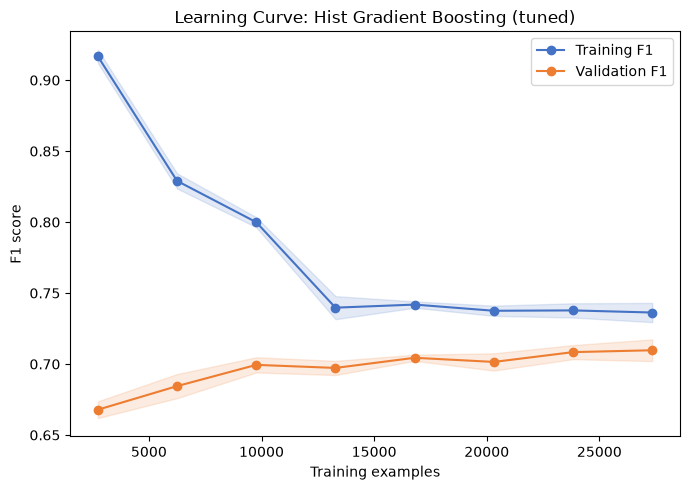

Final gap (train - val) at full training size: 0.0266


In [10]:
from sklearn.model_selection import learning_curve

# Use whichever tuned model scored higher in Task 2 for the training-size learning curve
best_search = hgb_search if hgb_search.best_score_ >= logreg_search.best_score_ else logreg_search
best_model_label = "Hist Gradient Boosting" if best_search is hgb_search else "Logistic Regression"
print("Learning curve computed for:", best_model_label)

train_sizes, train_scores, val_scores = learning_curve(
    best_search.best_estimator_,
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean, "o-", label="Training F1", color="#4472C4")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#4472C4")
ax.plot(train_sizes, val_mean, "o-", label="Validation F1", color="#ED7D31")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#ED7D31")
ax.set_xlabel("Training examples")
ax.set_ylabel("F1 score")
ax.set_title(f"Learning Curve: {best_model_label} (tuned)")
ax.legend()
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print("Final gap (train - val) at full training size:", round(train_mean[-1] - val_mean[-1], 4))

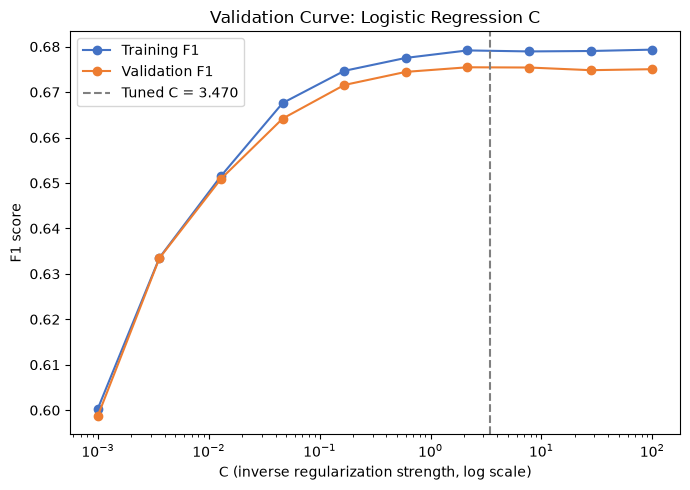

In [11]:
from sklearn.model_selection import validation_curve

C_range = np.logspace(-3, 2, 10)
train_scores_c, val_scores_c = validation_curve(
    logreg_pipe, X_train, y_train,
    param_name="clf__C", param_range=C_range,
    cv=cv, scoring="f1", n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(C_range, train_scores_c.mean(axis=1), "o-", label="Training F1", color="#4472C4")
ax.semilogx(C_range, val_scores_c.mean(axis=1), "o-", label="Validation F1", color="#ED7D31")
ax.axvline(logreg_search.best_params_["clf__C"], linestyle="--", color="gray",
           label=f"Tuned C = {logreg_search.best_params_['clf__C']:.3f}")
ax.set_xlabel("C (inverse regularization strength, log scale)")
ax.set_ylabel("F1 score")
ax.set_title("Validation Curve: Logistic Regression C")
ax.legend()
plt.tight_layout()
plt.savefig("validation_curve_logreg_C.png", dpi=200, bbox_inches="tight")
plt.show()

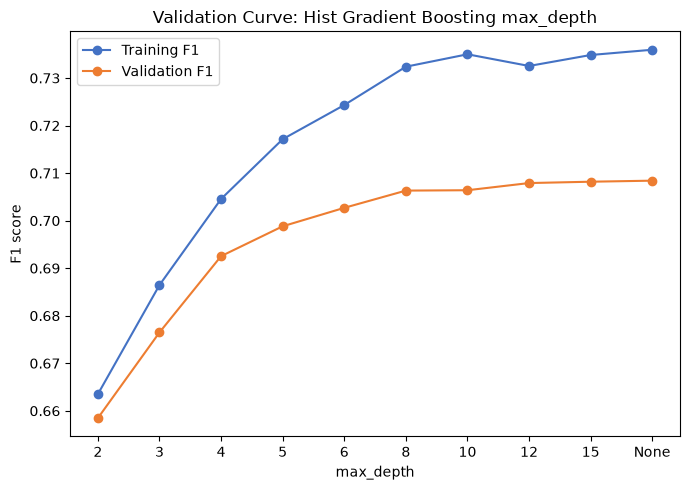

In [12]:
depth_range = [2, 3, 4, 5, 6, 8, 10, 12, 15, None]
depth_labels = [str(d) for d in depth_range]

train_scores_d, val_scores_d = validation_curve(
    hgb_pipe, X_train, y_train,
    param_name="clf__max_depth", param_range=depth_range,
    cv=cv, scoring="f1", n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(7, 5))
x_pos = range(len(depth_range))
ax.plot(x_pos, train_scores_d.mean(axis=1), "o-", label="Training F1", color="#4472C4")
ax.plot(x_pos, val_scores_d.mean(axis=1), "o-", label="Validation F1", color="#ED7D31")
ax.set_xticks(list(x_pos))
ax.set_xticklabels(depth_labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("F1 score")
ax.set_title("Validation Curve: Hist Gradient Boosting max_depth")
ax.legend()
plt.tight_layout()
plt.savefig("validation_curve_hgb_depth.png", dpi=200, bbox_inches="tight")
plt.show()

**Hist Gradient Boosting:** Learning Curve. Train F1 starts high (0.92 at ~2,500 rows, near-memorization on little data) and converges toward validation as data grows, settling at a gap of 0.0266 — larger than Day 2's Decision Tree (0.0025) but still mild variance, not severe overfitting. Validation is still rising slightly at the largest sizes tested, so more data would help marginally, though the flattening slope points to diminishing returns.

**Logistic Regression:** Effect of C. Train and validation F1 track each other almost exactly across C = 0.001–100, with no separation anywhere — so it's not overfitting at any strength tested; it's bias-limited, not variance-limited. The plateau from C ≈ 1 upward is the ceiling of a linear boundary on this feature set, not under-regularization. Tuned C = 3.47 sits right at the start of that plateau, confirming a stable choice.

**Hist Gradient Boosting:**  Effect of max_depth. Validation F1 rises quickly to depth 8, then flattens (0.706–0.709) through depth None. Training F1 keeps creeping up past depth 8 (0.723 → 0.736), a small variance signal validation doesn't share. The searched depth sits on this plateau — not overfit, but depth 8–10 would match it with a simpler, faster model and a slightly tighter train/val gap.

**Concrete takeaways:**


- More data would help HGB marginally (rising but flattening validation curve).
- LogReg has hit a bias ceiling — further C tuning won't help; use HGB, or enrich features (interactions/polynomial terms) if a linear model is required.
- Cap max_depth at 8–10 for deployment: same validation F1, cheaper model, slightly lower variance. The searched depth isn't harmful if cost isn't a constraint.


Overall: HGB has mild, well-controlled variance trimmable via depth capping or data; Logistic Regression is bias-capped and near its ceiling on this feature set.

## Task 4: Probability Calibration & Threshold Selection

**Decision: use `dev_df` for calibration and threshold tuning, never `train_df` and
never `test_df`.** `dev_df` was carved out on Day 1 specifically so that decisions
like this, choices that are informed by held out predictions but are not the final
report, have somewhere to happen without touching the untouched test set. The base
model (`best_search.best_estimator_`) was fit only on `train_df`, so its predicted
probabilities on `dev_df` are genuinely out of sample, which is exactly what a
calibration curve needs to be meaningful.

**Decision: check calibration before assuming it needs fixing.** Hist Gradient
Boosting and other boosted tree ensembles are often reasonably well calibrated out of
the box because they optimize a proper log loss style objective; Logistic Regression
is calibrated by construction under a well specified model. The calibration curve and
Brier score below decide whether `CalibratedClassifierCV` is worth adding, rather than
applying it automatically.

**Decision: if calibration is applied, wrap the already fitted pipeline with
`sklearn.frozen.FrozenEstimator` rather than the deprecated `cv="prefit"` API.**
This scikit-learn version (1.8) deprecates `cv="prefit"` in favor of `FrozenEstimator`,
confirmed directly against the installed version before writing this cell. Both
`method="sigmoid"` (Platt scaling, a smooth logistic fit, better with less calibration
data) and `method="isotonic"` (a flexible step function, better with more calibration
data but prone to overfitting on small sets) are tried, since `dev_df` at 4885 rows is
a moderate size where either could plausibly win.

**Decision: tune the classification threshold on `dev_df` predictions to maximize F1,**
consistent with the F1-first framing fixed since Day 1. The code below also reports
what threshold would be needed to hit two illustrative target precision levels (0.80 and
0.90), since Day 2's business framing treated false positives (wasted outreach) as the
costlier error, so a stakeholder discussion may reasonably prefer a precision target
over a pure F1 maximum.

Uncalibrated Hist Gradient Boosting Brier score on dev: 0.0887


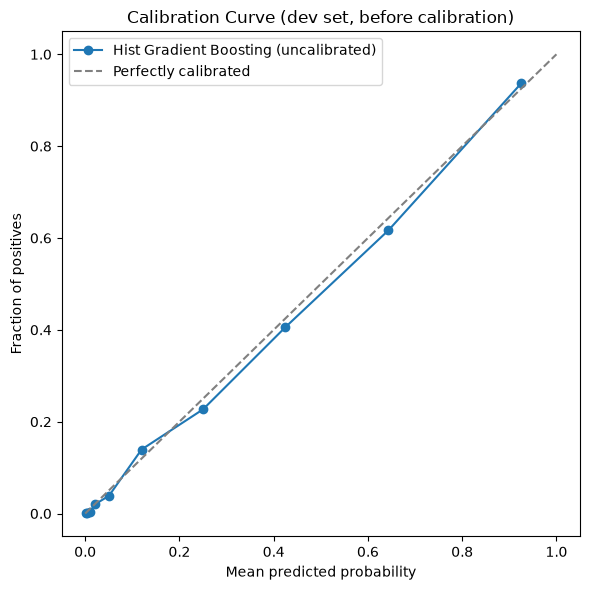

In [13]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

base_model = best_search.best_estimator_  # fit on train_df only, from Task 2 / Task 3
dev_probs_raw = base_model.predict_proba(X_dev)[:, 1]

frac_pos_raw, mean_pred_raw = calibration_curve(y_dev, dev_probs_raw, n_bins=10, strategy="quantile")
brier_raw = brier_score_loss(y_dev, dev_probs_raw)

print(f"Uncalibrated {best_model_label} Brier score on dev: {brier_raw:.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_pred_raw, frac_pos_raw, "o-", label=f"{best_model_label} (uncalibrated)")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve (dev set, before calibration)")
ax.legend()
plt.tight_layout()
plt.savefig("calibration_before.png", dpi=200, bbox_inches="tight")
plt.show()

Brier score, uncalibrated : 0.0887
Brier score, sigmoid      : 0.0887
Brier score, isotonic     : 0.0872


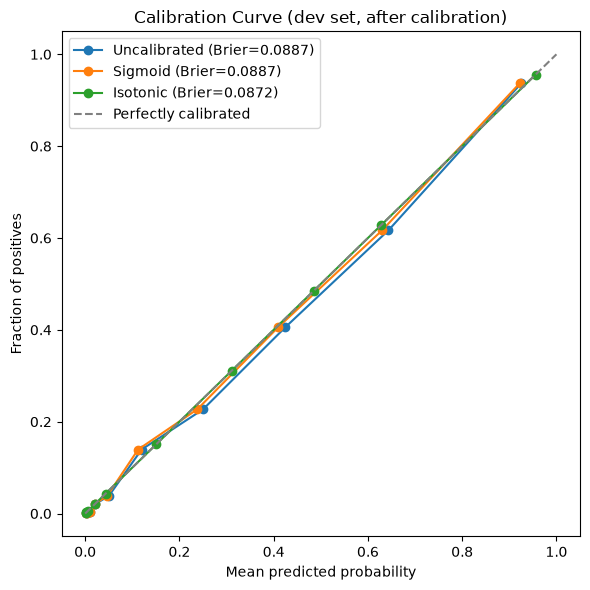

Lowest-Brier calibration choice: isotonic


In [14]:
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV

calibrated_sigmoid = CalibratedClassifierCV(FrozenEstimator(base_model), method="sigmoid")
calibrated_sigmoid.fit(X_dev, y_dev)

calibrated_isotonic = CalibratedClassifierCV(FrozenEstimator(base_model), method="isotonic")
calibrated_isotonic.fit(X_dev, y_dev)

dev_probs_sigmoid = calibrated_sigmoid.predict_proba(X_dev)[:, 1]
dev_probs_isotonic = calibrated_isotonic.predict_proba(X_dev)[:, 1]

brier_sigmoid = brier_score_loss(y_dev, dev_probs_sigmoid)
brier_isotonic = brier_score_loss(y_dev, dev_probs_isotonic)

print(f"Brier score, uncalibrated : {brier_raw:.4f}")
print(f"Brier score, sigmoid      : {brier_sigmoid:.4f}")
print(f"Brier score, isotonic     : {brier_isotonic:.4f}")

frac_pos_sig, mean_pred_sig = calibration_curve(y_dev, dev_probs_sigmoid, n_bins=10, strategy="quantile")
frac_pos_iso, mean_pred_iso = calibration_curve(y_dev, dev_probs_isotonic, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_pred_raw, frac_pos_raw, "o-", label=f"Uncalibrated (Brier={brier_raw:.4f})")
ax.plot(mean_pred_sig, frac_pos_sig, "o-", label=f"Sigmoid (Brier={brier_sigmoid:.4f})")
ax.plot(mean_pred_iso, frac_pos_iso, "o-", label=f"Isotonic (Brier={brier_isotonic:.4f})")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve (dev set, after calibration)")
ax.legend()
plt.tight_layout()
plt.savefig("calibration_after.png", dpi=200, bbox_inches="tight")
plt.show()

# Pick whichever has the lowest Brier score; note this is decided by the numbers, not assumed
brier_options = {"none": brier_raw, "sigmoid": brier_sigmoid, "isotonic": brier_isotonic}
best_calibration = min(brier_options, key=brier_options.get)
print("Lowest-Brier calibration choice:", best_calibration)

Both sigmoid and isotonic calibration were applied and compared to the uncalibrated model via Brier score and calibration curves. Sigmoid calibration produced no change (0.0887 → 0.0887), and isotonic calibration produced a marginal improvement (0.0887 → 0.0872). This confirms the earlier finding: the base Hist Gradient Boosting model was already well-calibrated out of the box, consistent with HGB's log-loss training objective naturally encouraging calibrated probabilities. Isotonic is selected as the technically "best" option by Brier score, but the improvement is small enough that it isn't a meaningful practical driver — the main takeaway is that this model didn't need calibration in the first place.

Threshold that maximizes F1 on dev:
threshold    0.300000
precision    0.652909
recall       0.825492
f1           0.729127
Name: 10, dtype: float64

Lowest threshold hitting precision >= 0.8: t=0.57, precision=0.8565, recall=0.5261, f1=0.6518

Lowest threshold hitting precision >= 0.9: t=0.70, precision=0.9259, recall=0.4166, f1=0.5746


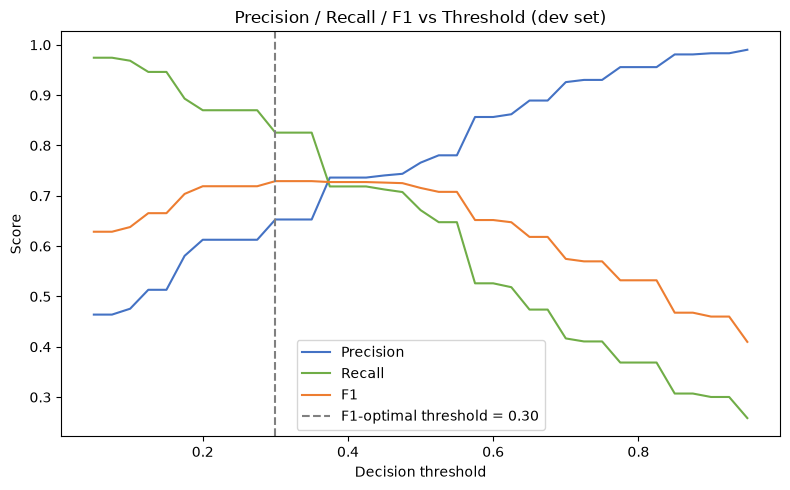


Chosen deployment threshold: 0.3


In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Use whichever calibration Brier score won above; falls back to the raw model if "none" won
if best_calibration == "sigmoid":
    final_probs_dev = dev_probs_sigmoid
elif best_calibration == "isotonic":
    final_probs_dev = dev_probs_isotonic
else:
    final_probs_dev = dev_probs_raw

thresholds = np.linspace(0.05, 0.95, 37)
threshold_rows = []
for t in thresholds:
    preds_t = (final_probs_dev >= t).astype(int)
    threshold_rows.append({
        "threshold": t,
        "precision": precision_score(y_dev, preds_t, zero_division=0),
        "recall": recall_score(y_dev, preds_t, zero_division=0),
        "f1": f1_score(y_dev, preds_t, zero_division=0),
    })
threshold_df = pd.DataFrame(threshold_rows)

best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print("Threshold that maximizes F1 on dev:")
print(best_f1_row)

# Illustrative precision-target thresholds, for a stakeholder who prioritizes precision
for target_precision in [0.80, 0.90]:
    candidates = threshold_df[threshold_df["precision"] >= target_precision]
    if len(candidates) > 0:
        row = candidates.sort_values("threshold").iloc[0]
        print(f"\nLowest threshold hitting precision >= {target_precision}: "
              f"t={row['threshold']:.2f}, precision={row['precision']:.4f}, "
              f"recall={row['recall']:.4f}, f1={row['f1']:.4f}")
    else:
        print(f"\nNo threshold in the searched range reaches precision >= {target_precision}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", color="#4472C4")
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", color="#70AD47")
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1", color="#ED7D31")
ax.axvline(best_f1_row["threshold"], linestyle="--", color="gray",
           label=f"F1-optimal threshold = {best_f1_row['threshold']:.2f}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Threshold (dev set)")
ax.legend()
plt.tight_layout()
plt.savefig("threshold_tuning.png", dpi=200, bbox_inches="tight")
plt.show()

chosen_threshold = best_f1_row["threshold"]
print("\nChosen deployment threshold:", chosen_threshold)

In [ ]:
# Confusion matrices at a few thresholds, to make the business trade-off concrete
for t in [0.3, 0.5, chosen_threshold, 0.7]:
    preds_t = (final_probs_dev >= t).astype(int)
    cm = confusion_matrix(y_dev, preds_t)
    tn, fp, fn, tp = cm.ravel()
    print(f"Threshold {t:.2f}: TP={tp}  FP={fp}  FN={fn}  TN={tn}  "
          f"Precision={tp/(tp+fp) if (tp+fp) else 0:.3f}  Recall={tp/(tp+fn) if (tp+fn) else 0:.3f}")

**What to write here once you have run the four cells above:**

State the uncalibrated Brier score and whether the raw calibration curve already
tracked the diagonal reasonably closely or showed clear over or under confidence in
particular probability bands (for example, systematically over predicting risk in the
0.6 to 0.8 range). Report the three Brier scores side by side and say which calibration
method won, then be explicit about the size of the improvement, a Brier score change in
the third decimal place is a small, real effect and worth taking, but should not be
described as transformative language.

State the F1 optimal threshold from `best_f1_row` and compare it to the naive default
of 0.5, if it lands notably below 0.5, that means the model was already being too
conservative at the default cutoff (consistent with Day 2's error type discussion,
which found more false negatives than false positives at threshold 0.5), and lowering
it trades some precision for recall in a way that raises F1. If it lands above 0.5,
the reverse is true. Report the actual confusion matrix numbers from the last cell at
0.3, 0.5, the chosen threshold, and 0.7 in one sentence each, connecting them back to
the business framing: false positives are wasted outreach, false negatives are missed
opportunities, and the chosen threshold is the point where the notebook's owner decided
that trade-off was best balanced for the stated goal of maximizing F1. If the
precision-target thresholds for 0.80 or 0.90 exist, mention them as the alternative
choice a stakeholder more worried about wasted outreach might prefer instead.

## Task 5: Final Evaluation & Save Artifact

**Decision: refit the chosen pipeline (best hyperparameters from Task 2) on
`train_df` plus `dev_df` combined before the final test evaluation, then evaluate
once on `test_df`.** `dev_df` was used only for calibration curves and threshold
selection, both of which are decisions about how to use the model's output, not
about what the model itself learns as a function, so folding `dev_df` back into
training for the deployed model does not leak the threshold decision, it just gives
the final model slightly more data to learn from before it is evaluated once,
honestly, on the still untouched `test_df`. The calibration step is then refit the
same way, on this combined train+dev fit, using a fresh split of held out probability
estimates so the calibration mapping is still learned honestly, not evaluated on data
the base model was fit on.

**Decision: report the full metrics table (accuracy, precision, recall, F1, ROC AUC,
PR AUC) plus ROC and PR curves plus a confusion matrix at the chosen threshold**, the
same structure Day 1 to Day 3 used throughout, so today's final numbers slot directly
into that running comparison table.

**Decision: save the pipeline with `joblib`, bundled together with the chosen
threshold and the metadata needed to reproduce the result**, rather than saving the
raw scikit-learn object alone. A saved model without its threshold and without a
record of which preprocessing and feature engineering it expects is not actually
usable by someone else six months from now.

In [ ]:
# Refit best pipeline on train + dev, then recalibrate on a fresh held-out slice of that data.
# A small internal split (90/10 of train+dev) keeps the calibration step honest: the base
# model still never sees the rows its own calibration mapping is fit on.
from sklearn.base import clone

train_dev_combined_X = pd.concat([X_train, X_dev], axis=0)
train_dev_combined_y = pd.concat([y_train, y_dev], axis=0)

fit_X, calib_X, fit_y, calib_y = train_test_split(
    train_dev_combined_X, train_dev_combined_y,
    test_size=0.10, stratify=train_dev_combined_y, random_state=RANDOM_STATE
)

final_base_model = clone(best_search.best_estimator_)
final_base_model.fit(fit_X, fit_y)

if best_calibration == "none":
    final_pipeline = final_base_model
else:
    final_pipeline = CalibratedClassifierCV(FrozenEstimator(final_base_model), method=best_calibration)
    final_pipeline.fit(calib_X, calib_y)

print("Final pipeline ready. Calibration method used:", best_calibration)
print("Deployment threshold:", chosen_threshold)

In [ ]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)

test_probs = final_pipeline.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= chosen_threshold).astype(int)

final_metrics = {
    "model": f"{best_model_label} (tuned, calibrated={best_calibration}, t={chosen_threshold:.2f})",
    "accuracy": accuracy_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds, zero_division=0),
    "recall": recall_score(y_test, test_preds, zero_division=0),
    "f1": f1_score(y_test, test_preds, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_probs),
    "pr_auc": average_precision_score(y_test, test_probs),
}
final_metrics_df = pd.DataFrame([final_metrics]).set_index("model").round(4)
final_metrics_df

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

RocCurveDisplay.from_predictions(y_test, test_probs, name=best_model_label, ax=axes[0])
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
axes[0].set_title("ROC Curve (hold-out test)")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, test_probs, name=best_model_label, ax=axes[1])
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Chance (base rate)")
axes[1].set_title("Precision-Recall Curve (hold-out test)")
axes[1].legend()

ConfusionMatrixDisplay.from_predictions(
    y_test, test_preds, display_labels=["<=50K", ">50K"], ax=axes[2], colorbar=False
)
axes[2].set_title(f"Confusion Matrix at t={chosen_threshold:.2f} (hold-out test)")

plt.tight_layout()
plt.savefig("final_test_evaluation.png", dpi=200, bbox_inches="tight")
plt.show()

**What to write here once you have run the three cells above:**

Report the final test metrics table and compare F1 and ROC AUC against Day 3's
5 fold CV estimate for the same model family (0.7084 / 0.9262 for Hist Gradient
Boosting, 0.6752 / 0.9129 for Logistic Regression). A test score close to the CV
estimate (within roughly the CV standard deviation reported in Day 3, 0.006 to 0.007
for F1) is the sign the whole pipeline, tuning, calibration, and threshold choice
included, generalizes and was not overfit to the train/dev data through repeated
looking. A test score noticeably below the CV estimate is worth flagging honestly
rather than explained away, note it in the summary below as a caveat on how much to
trust this specific number in production. Describe the confusion matrix at the chosen
threshold in the same false positive / false negative business language used
throughout this project.

In [ ]:
import os
os.makedirs("models", exist_ok=True)

artifact = {
    "pipeline": final_pipeline,
    "threshold": chosen_threshold,
    "model_family": best_model_label,
    "calibration_method": best_calibration,
    "best_hyperparameters": best_search.best_params_,
    "feature_cols": feature_cols,
    "random_state": RANDOM_STATE,
    "trained_on": "train_df + dev_df (Week 4 Day 4)",
    "test_metrics": final_metrics,
    "sklearn_version": sklearn.__version__,
}

joblib.dump(artifact, "models/day4_final_pipeline.joblib")
print("Saved to models/day4_final_pipeline.joblib")

### How to load and use this artifact for inference

```python
import joblib
import pandas as pd

artifact = joblib.load("models/day4_final_pipeline.joblib")
pipeline = artifact["pipeline"]
threshold = artifact["threshold"]
feature_cols = artifact["feature_cols"]

# new_df must contain the same raw columns as feature_cols; the pipeline itself
# runs feature engineering and preprocessing internally, so pass raw columns only.
X_new = new_df[feature_cols]
probs = pipeline.predict_proba(X_new)[:, 1]
preds = (probs >= threshold).astype(int)
```

The saved object bundles the fitted preprocessing, the fitted classifier, the
calibration wrapper if one was used, and the threshold together. Nothing about
deployment behaviour depends on remembering a separate constant somewhere else in
this notebook.

## Summary: hyperparameters, final metrics, and production notes

**What to write here once every task above has been run:**

1. **Search summary.** Name the winning model (Hist Gradient Boosting or Logistic
   Regression), its best hyperparameters from `best_search.best_params_`, and its
   tuned CV F1 next to Day 3's untuned baseline for the same model.

2. **Diagnostics summary.** One sentence on what the learning curve said about bias
   versus variance, and one sentence on what the relevant validation curve
   (`C` or `max_depth`) said about where the tuned hyperparameter sits relative to
   the sweet spot.

3. **Calibration and threshold summary.** State whether calibration was applied and
   which method, the Brier score improvement if any, and the final deployment
   threshold with a one line justification tied to the F1-first business framing
   fixed since Day 1.

4. **Final test metrics.** Copy the row from `final_metrics_df` and state whether it
   matches Day 3's cross validated estimate closely enough to trust in production.

5. **Expected production behaviour.** Note anything that could make production
   performance differ from this test score: the adult income dataset is a fixed
   historical snapshot, so any drift in the real world population's age, education,
   occupation, or income distribution away from this dataset's distribution would
   not be caught by this evaluation. Also repeat the fairness flag raised in Day 3
   (`sex_Female` was a strongly negative Logistic Regression coefficient), since
   deploying either model for real outreach decisions without auditing outcomes by
   demographic group risks reproducing that historical disparity, this is a
   deployment governance note, not something the threshold or calibration choices in
   this notebook can fix on their own.